# Aprendizado Supervisionado - Classificação

Fontes da aula de hoje:
1. Capítulos 19 do *Livro Data Mining and Machine Learning: Fundamental Concepts and Algorithms* (https://dataminingbook.info/book_html/)

3. Várias páginas da documentação da ``scikit-learn``

3. Aulas do Professor Mark Crovella [aqui](https://github.com/mcrovella/CS506-Computational-Tools-for-Data-Science/blob/master/15-Classification-II-kNN.ipynb), [aqui](https://github.com/mcrovella/CS506-Computational-Tools-for-Data-Science/blob/master/14-Classification-I-Decision-Trees.ipynb) e [aqui](https://github.com/mcrovella/DS701-Tools-for-Data-Science/blob/main/16-Classification-III-NB-SVM.ipynb).


# Introdução

Aprendizado supervisionado é uma área de aprendizado de máquina que tem o objetivo de **aprender** a partir de dados "rotulados".

Há duas tarefas principais:
* Regressão
* Classificação

Nesse contexto, os objetos de estudo serão uma matriz $\mathbf{X} \in \mathbb{R}^{n \times d}$ e um vetor $\mathbf{y}$, onde:
* $n$ é o número de objetos; e
* $d$ é a dimensionalidade de cada objeto.
* $y_i$ é o rótulo (ou valor) associado a $\mathbf{x}_i$

Nessa disciplina, focaremos em **classificação**, mas boa parte dos conceitos também se aplicam à **regressão**.

## Exemplo Clássico - Reconhecimento de Dígitos

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import datasets
import seaborn as sns

sns.set()

In [ ]:
digits = datasets.load_digits(return_X_y = False)
df = pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


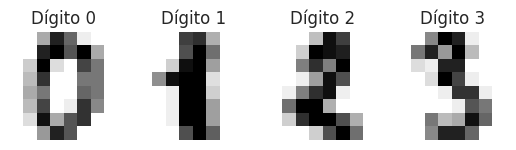

In [ ]:
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Dígito %i' % label)

**Perguntas:**

*  Dada uma imagem de um número, qual é o dígito equivalente?
*  Qual o custo de uma predição errada?

# O problema de Classificação (uma definição simplificada)

Dados $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, a tarefa de classificação consiste em encontrar um modelo $f$ que aprenda dos vetores de características os rótulos.

No exemplo acima, quem seriam os $\mathbf{x}_i$'s e $y_i$'s?

## Qualquer $f$ serve?

Há dois requisitos principais:

1. Se $(\mathbf{x}, y) \in D$, então $f(\mathbf{x}) = y$ com alta probabilidade.

2. A função aprendida deve ser **generalizável**. Se um novo $\mathbf{x}$ não pertencente ao conjunto $D$ for observado, deseja-se também que $f(\mathbf{x})$ seja o rótulo correto de $\mathbf{x}$ com alta probabilidade.

- **Satisfazer apenas o requisito 1 é fácil!**
- **Satisfazer 1 e 2 simultaneamente é difícil!**

## *Dumb Classifier*

### Pergunta

Qual seria um classificador simples que satisfaz o requisito (1), mas não satisfaz (2)?

### Resposta

Seja $\mathbf{x}$ um elemento a ser classificado. Considere o seguinte classificador:

$$f(\mathbf{x}) = \begin{cases} \text{Se } \mathbf{x} \text{ está em } D \text{, retorne o rótulo associado}\\
\text{Caso contrário, retorne um rótulo aleatório (uniformemente entre os rótulos válidos)}.
\end{cases}$$

Veja que $f$ acerta em 100% dos casos em que $\mathbf{x}$ está em $D$. Logo, o requisito (1) é satisfeito.

Mas e o requisito 2? O classificador proposto é incapaz de generalizar para situações não conhecidas.

Esse problema está relacionado ao conceito de **overfitting**.

### Overfitting

Ocorre quando o modelo explica tão bem o conjunto de dados usado durante o aprendizado, que é incapaz de generalizar para dados não vistos.

Considere o seguinte exemplo para a tarefa de regressão (da biblioteca [scikit-learn](http://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)):

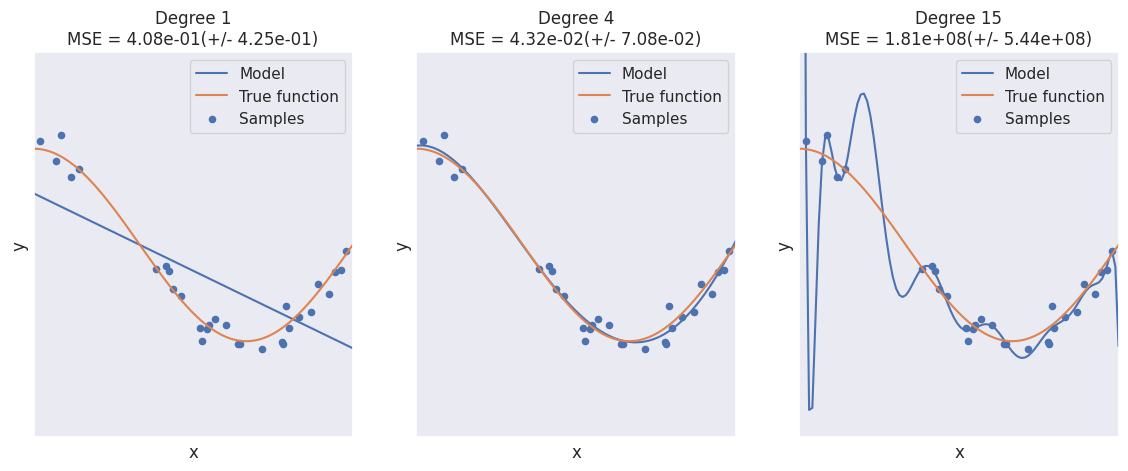

In [ ]:
#@title Exemplo de overfitting

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(pipeline, X[:, np.newaxis], y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))
plt.show()

Nessa disciplina, veremos:
1. Algumas formas interessantes de se construir bons modelos
2. Metodologias experimentais para garantir que nosso modelo seja **bom** e **generalizável**.

# $k$ Vizinhos mais próximos - KNN

Como para qualquer classificador, o KNN ($k$-*Nearest Neighbors*) é treinado com um conjunto rotulado de dados (comumente chamado de conjunto de treino).

No entanto, o treinamento do classificador faz muito pouco. Ele apenas armazena o conjunto de dados (instâncias e rótulos).

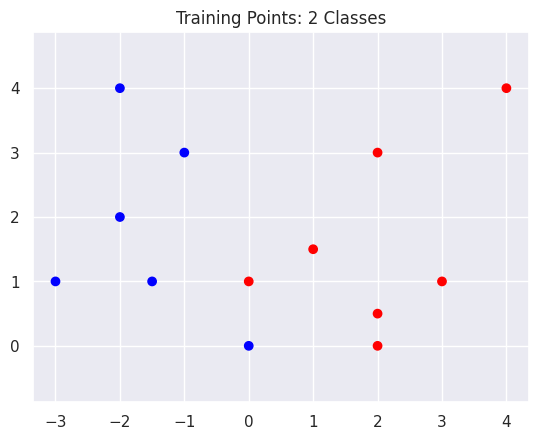

In [ ]:
#@title KNN - Exemplo - Dados

from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

sns.set()

demo_y = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
demo_X = np.array([[-3,1], [-2, 4], [-2, 2], [-1.5, 1], [-1, 3], [0, 0], [1, 1.5], [2, 0.5], [2, 3], [2, 0], [3, 1], [4, 4], [0, 1]])
test_X = [-0.3, 0.7]
#
plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap_bold)
plt.axis('equal')
#plt.axis('off')
plt.title('Training Points: 2 Classes');

A ideia do classificador KNN é que, na tarefa de teste (i.e., classificar uma instância desconhecida), ele simplesmente "olha" os pontos do conjunto de treinamento que estão mais próximos do ponto consultado. A classe de retorno é baseada na classe de tais "vizinhos".

Por "mais próximo", geralmente, estamos falando em termos de distância Euclidiana.

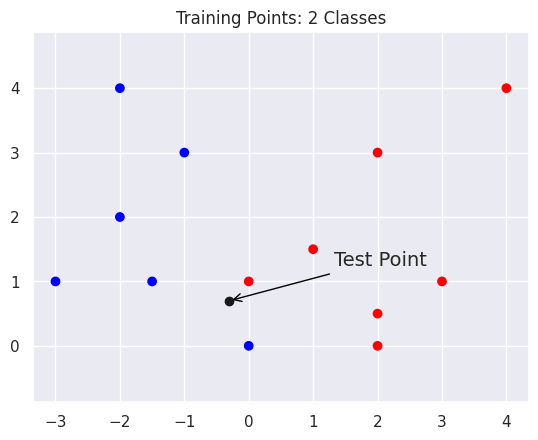

In [ ]:
#@title KNN - Exemplo - Teste

plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap_bold)
plt.plot(test_X[0], test_X[1], 'ok')
plt.annotate('Test Point', test_X, [75, 25],
             textcoords = 'offset points', fontsize = 14,
             arrowprops = {'arrowstyle': '->', 'color': 'black'})
plt.axis('equal')
plt.title('Training Points: 2 Classes');

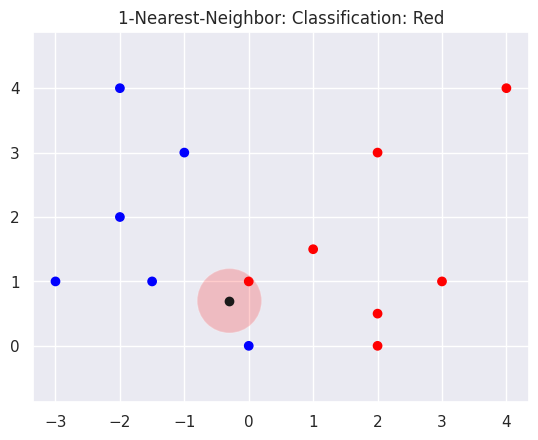

In [ ]:
#@title KNN - Exemplo - 1NN

import matplotlib as mp

plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap_bold)
plt.plot(test_X[0], test_X[1], 'ok')
ax=plt.gcf().gca()
circle = mp.patches.Circle(test_X, 0.5, facecolor = 'red', alpha = 0.2)
plt.axis('equal')
ax.add_artist(circle)
plt.title('1-Nearest-Neighbor: Classification: Red');

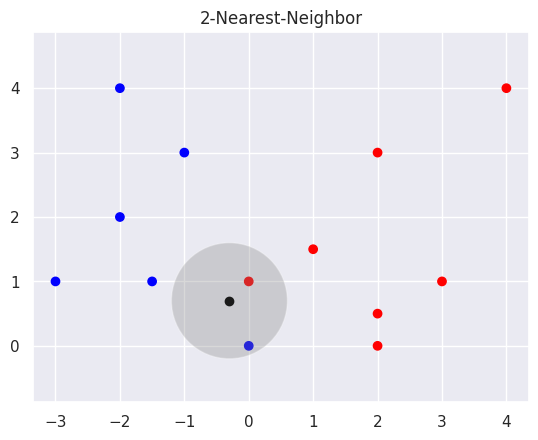

In [ ]:
#@title KNN - Exemplo -2NN

plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap_bold)
test_X = [-0.3, 0.7]
plt.plot(test_X[0], test_X[1], 'ok')
ax=plt.gcf().gca()
    #ellipse = mp.patches.Ellipse(gmm.means_[clus], 3 * e[0], 3 * e[1], angle, color = 'r')
circle = mp.patches.Circle(test_X, 0.9, facecolor = 'gray', alpha = 0.3)
plt.axis('equal')
ax.add_artist(circle)
plt.title('2-Nearest-Neighbor');

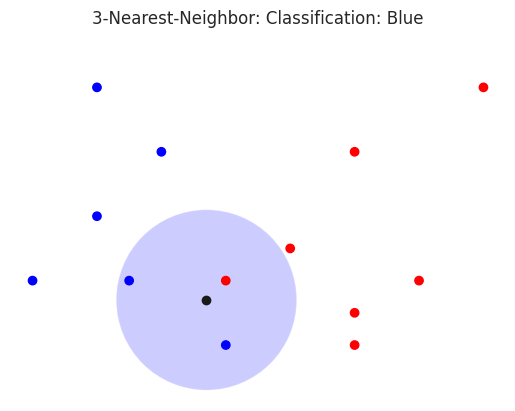

In [ ]:
#@title KNN - Exemplo - 3NN
plt.figure()
ax=plt.gcf().gca()
    #ellipse = mp.patches.Ellipse(gmm.means_[clus], 3 * e[0], 3 * e[1], angle, color = 'r')
circle = mp.patches.Circle(test_X, 1.4, facecolor = 'blue', alpha = 0.2)
ax.add_artist(circle)
plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap_bold)
test_X = [-0.3, 0.7]
plt.plot(test_X[0], test_X[1], 'ok')
plt.axis('equal')
plt.axis('off')
plt.title('3-Nearest-Neighbor: Classification: Blue');

## Funcionamento do KNN



Os exemplos acima, ilustram bem o funcionamento do KNN.

#### Entrada

- um conjunto de treinamento $D = \{(\mathbf{x}_i, y_i)\}_{i = 1}^n$;
- um inteiro $k$ (o "K" do KNN); e
- um ponto de interesse, $\mathbf{x}$, a ser classificado

#### Algoritmo

1. Encontre no conjunto de treinamento, $D$, os $k$ elementos mais próximos de $\mathbf{x}$ e suas respectivas classes.
2. Retorne a classe mais popular entre os $k$ vizinhos mais próximos de $\mathbf{x}$.

## Perguntas importantes

1. Como implementar de forma eficiente?
2. Como escolher $k$?
3. Como usar na ``scikit-learn``?

### Respostas

1. Há Estruturas de Dados apropriadas para a tarefa (basicamente, são alguns tipos especiais de árvores);

2. Nos exemplos a seguir, veremos que a escolha de $k$ é importante! Observe que $k$ é um valor que deve ser **fornecido pelo usuário do classificador**. Em aprendizado de máquina, essas quantidades são chamadas de **hiperparâmetros**.
Um procedimento adequado para escolha de hiperparâmetros será apresentado em aulas futuras.

3. Fácil (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). Já já veremos um exemplo.

## Exemplo I - Impacto do valor de $k$

Considere o conjunto de treinamento apresentado na figura abaixo.

De forma análoga ao exemplo anterior, nesse conjunto há **duas características** (``A`` e ``B``) e três classes (``Vermelho``, ``Azul`` e ``Verde``).

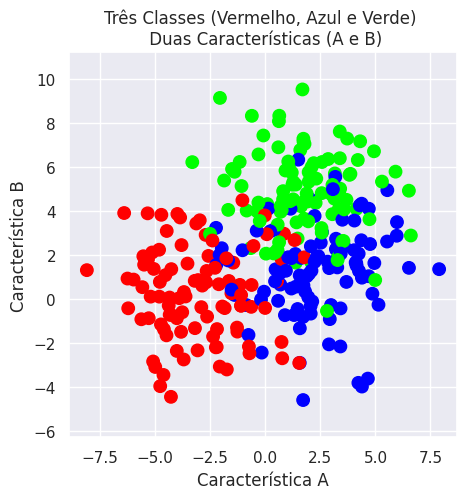

In [ ]:
#@title Conjunto de Dados
import sklearn.datasets as sk_data
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

X, y = sk_data.make_blobs(n_samples=300,
                          centers=[[-3, 0],[2, 5], [2.5, 1.5]],
                          #centers=[[-2, 0],[1, 5], [2.5, 1.5]],
                          cluster_std = [2, 2, 2],
                          #cluster_std = [2, 2, 2],
                          n_features=2,
                          center_box=(-10.0, 10.0),random_state=0)
plt.figure(figsize = (5,5))
plt.axis('equal')
plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold, s = 80);

plt.xlabel('Característica A')
plt.ylabel('Característica B')
plt.title('Três Classes (Vermelho, Azul e Verde) \n Duas Características (A e B)');

Se variarmos o valor de $k$, haverá impacto nos resultados das classificações?

Para responder a essa pergunta, vamos observar o que ocorre com as **regiões de decisão** para vários valores de $k$.

A figura abaixo apresenta as regiões de decisão para $k = 25$.

Em outras palavras, pontos a serem classificados que estiverem na região verde, serão classificados como sendo da classe ``Verde``. De forma análoga, o mesmo vale para pontos que estiverem nas regiões azul e vermelha.

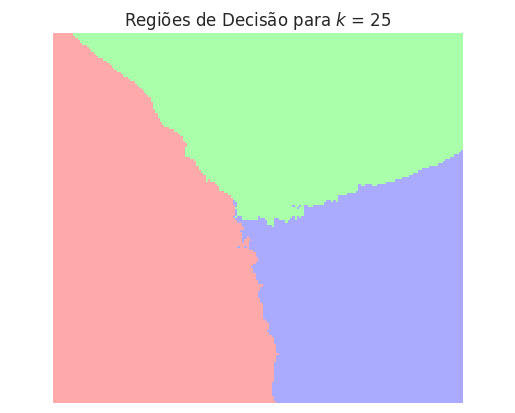

In [ ]:
#@title
from sklearn.neighbors import KNeighborsClassifier

h = .1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

k = 25
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X, y)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.pcolormesh(xx, yy, Z, cmap = cmap_light, shading = 'auto')
plt.axis('equal')
plt.axis('off')
plt.title(f'Regiões de Decisão para $k$ = {k}');

Vejamos o que acontece para outros valores de $k$.

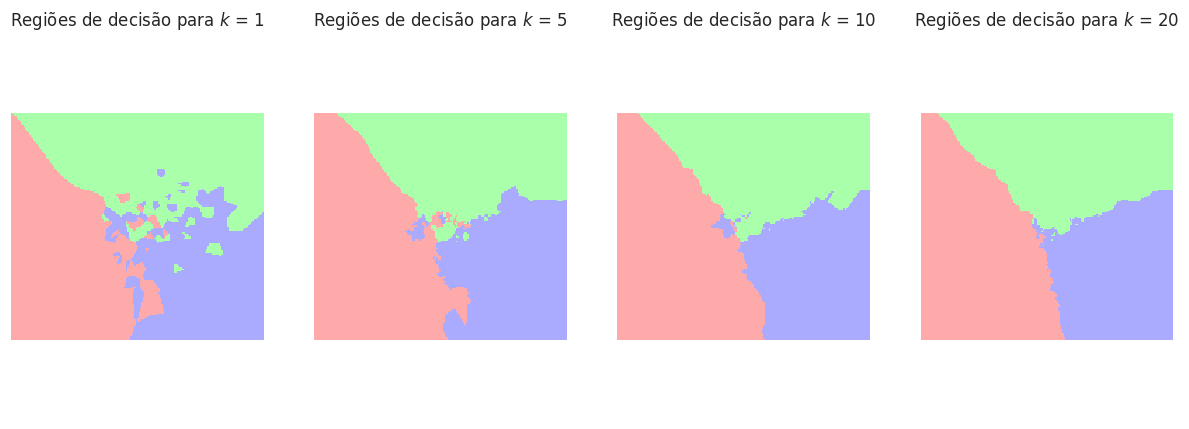

In [ ]:
#@title
from sklearn.neighbors import KNeighborsClassifier


h = .1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

f, axs = plt.subplots(1, 4, figsize=(15, 5))
for i, k in enumerate([1, 5, 10, 20]):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axs[i].pcolormesh(xx, yy, Z, cmap = cmap_light, shading = 'auto')
    axs[i].axis('equal')
    axs[i].axis('off')
    axs[i].set_title(f'Regiões de decisão para $k$ = {k}');

Pelos resultados obtidos, podemos perceber que a escolha de $k$ impacta muito os resultados das classificações!

## Exemplo II - Utilizando o KNN na ``scikit-learn``

A biblioteca ``scikit-learn`` possui uma implementação do KNN que pode ser utilizada de maneira muito simples.

A documentação pode ser consultada [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

Para exemplificar o uso do KNN na ``scikit-learn``, vamos usar o conjunto de dados ``wine``.

In [ ]:
wine = datasets.load_wine(return_X_y = False, as_frame = True)
X = wine.data
y = wine.target.values

In [ ]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

Primeiro, antes de treinar um classificador, sempre é importante reter uma porção do conjunto de dados para realização de testes.

Treinar e testar um classificador no mesmo conjunto de dados pode gerar resultados **não generalizáveis** (assunto a ser detalhado em aulas futuras).

Abaixo, 30% do conjunto de dados é separado para testes. Essa porção dos dados não deve ser utilizada para nada durante a construção do classificador.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

Como o KNN é um classificador baseado em distâncias, é transformar os dados para que todas as colunas estejam na mesma ordem de grandeza.

Abaixo, usamos a transformação por reescala para tal tarefa.

Observe que o ``scaler`` é construído considerando apenas os objetos do **conjunto de treinamento**.

In [ ]:
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

Na ``scikit-learn``, o KNN está implementado na classe ``KNeighborsClassifier``.

Ao instanciar essa classe, o valor de $k$ deve ser fornecido. No exemplo a seguir, $k = 5$ foi utilizado apenas a título de exemplo. Não há garantias de que essa seja a melhor escolha.

O método ``fit`` é utilizado para treinar o classificador com os dados transformados (``X_train_scaled``) e seus respectivos rótulos (``y_train``). O classificador treinado é armazenado na variável ``model``.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k = 5
model = KNeighborsClassifier(n_neighbors = k)
model.fit(X_train_scaled, y_train);

Uma vez que o classificador está treinado, ele pode ser utilizado para prever os rótulos dos objetos do conjunto de teste. Para isso, podemos utilizar o método ``predict``.

No entanto, antes disso, deve-se aplicar aos dados do conjunto de teste a **mesma transformação** que foi aplicada aos dados do conjunto de treinamento. Observe que o ``scaler`` sendo utilizado abaixo é o mesmo que foi construído anteriormente.

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled);

Para saber se o classificador treinado se saiu bem no conjunto de teste, podemos comparar o vetor ``y_test`` (rótulos reais) com o vetor ``y_pred`` (rótulos preditos pelo classificador).

In [ ]:
y_test

array([0, 0, 0, 0, 2, 2, 1, 0, 2, 1, 1, 0, 2, 1, 1, 2, 0, 2, 1, 2, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 0, 2, 2, 1, 0,
       0, 1, 1, 1, 2, 0, 2, 2, 1, 0])

In [ ]:
y_pred

array([0, 0, 0, 0, 2, 2, 1, 0, 2, 1, 1, 0, 2, 1, 1, 2, 0, 2, 1, 2, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 1, 2, 1, 2, 2, 0, 2, 2, 1, 0,
       0, 1, 1, 1, 2, 0, 2, 2, 1, 0])

Uma maneira de fazer tal comparação é verificando a fração de posições dos dois vetores que possuem valores iguais. Essa quantidade é conhecida como **Acurácia**. O código abaixo mostra como calcular a acurácia utilizando a ``scikit-learn``.

**Observação:** há várias outras formas de se avaliar um classificador treinado. Veremos mais sobre isso em aulas futuras.

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Acurácia do Classificador = %f" % acc)

Acurácia do Classificador = 0.962963


Pode-se perceber que o classificador obteve uma acurácia relativamente alta. Indicando que o KNN é um classificador adequado para esse conjunto de dados.

## Exemplo III - Impacto do $k$ na acurácia

Vamos ver o que acontece com a acurácia do classificador, nesse conjunto de dados, para diferentes valores de $k$.

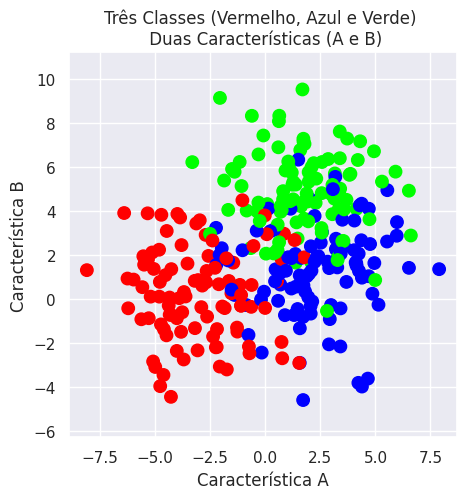

In [ ]:
#@title Conjunto de Dados
import sklearn.datasets as sk_data
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

X, y = sk_data.make_blobs(n_samples=300,
                          centers=[[-3, 0],[2, 5], [2.5, 1.5]],
                          #centers=[[-2, 0],[1, 5], [2.5, 1.5]],
                          cluster_std = [2, 2, 2],
                          #cluster_std = [2, 2, 2],
                          n_features=2,
                          center_box=(-10.0, 10.0),random_state=0)
plt.figure(figsize = (5,5))
plt.axis('equal')
plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold, s = 80);

plt.xlabel('Característica A')
plt.ylabel('Característica B')
plt.title('Três Classes (Vermelho, Azul e Verde) \n Duas Características (A e B)');

Primeiro, vamos dividir os dados em porções de treino e teste.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30,
                                                    random_state = 7)

A função abaixo encapsula as boas práticas de treinamento do KNN:
- Definição da transformação por reescala
- Treinamento do classificador no conjunto de treinamento
- Transformação dos dados do conjunto de teste
- Aplicação do classificador treinado no conjunto de teste
- Cálculo da acurácia

Para fins de comparação, o classificador também foi utilizado para prever os rótulos do conjunto de treinamento.

In [ ]:
def evaluate_knn(k, X_train, X_test, y_train, y_test):
  scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
  scaler.fit(X_train)
  X_train_scaled = scaler.transform(X_train)

  model = KNeighborsClassifier(n_neighbors = k)
  model.fit(X_train_scaled, y_train);

  X_test_scaled = scaler.transform(X_test)
  y_pred_test = model.predict(X_test_scaled)

  y_pred_train = model.predict(X_train_scaled)

  return accuracy_score(y_test, y_pred_test), accuracy_score(y_train, y_pred_train)

A seguir, são computadas as acurácias nos conjuntos de treinamento e teste para diferentes valores de $k$.

In [ ]:
k_values = list(range(1, 26))
acc_test, acc_train = zip(*[evaluate_knn(k, X_train, X_test, y_train, y_test) for k in k_values])

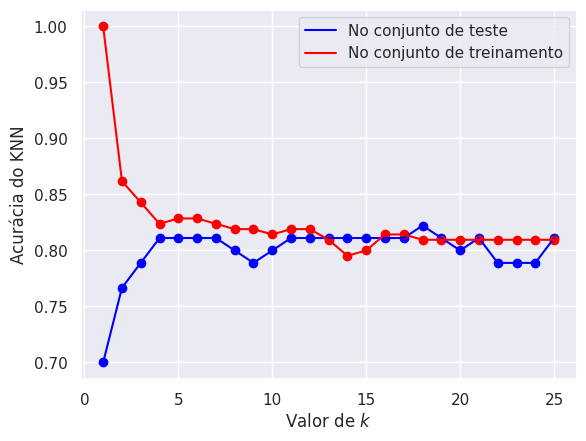

In [ ]:
#@title Comparação das Acurácias do KNN
import matplotlib.pyplot as plt

plt.scatter(k_values, acc_test, color = 'blue');
plt.plot(k_values, acc_test, color = 'blue', label = 'No conjunto de teste');
plt.scatter(k_values, acc_train, color = 'red');
plt.plot(k_values, acc_train, color = 'red', label = 'No conjunto de treinamento');
plt.xlabel(r'Valor de $k$')
plt.ylabel('Acurácia do KNN')
plt.legend(loc = 'best');

Nas próximas aulas, veremos como essa escolha pode ser feita de maneira adequada.

# Introdução ao Classificador Naive Bayes

Na aula de hoje, veremos uma terceira maneira de fazer classificação de dados: o Classificador **Naive Bayes**.

O **Naive Bayes** também tenta estimar a probabilidade de uma determinada classe, dado um vetor de características.

Antes de explicar como o classificador funciona, precisamos revisitar alguns conceitos fundamentais de probabilidade.

Após isso, como de costume, vamos apresentar a intuição de como **Naive Bayes** funciona fazendo uso de um exemplo prático.

## Preliminares - A Regra de Bayes

Começaremos da definição de probabilidade condicional.

**Definição:** Dados dois eventos, $A$ e $C$, a probabilidade do evento $A$ ocorrer dado que o evento $C$ ocorreu é dada por
$$P[A | C] = \frac{P[A \cap C]}{P[C]},$$
onde $P[A \cap C]$ é a probabilidade de ambos, $A$ e $C$, ocorrerem.

Da definição, tem-se que:
$$P[A \cap C] = P[A|C]\cdot P[C].$$


A Figura abaixo representa os eventos $A$, $C$ e $A \cap C$.

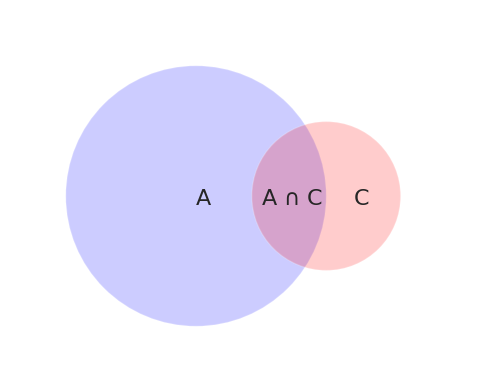

In [ ]:
#@title
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mp
import sklearn

plt.figure(figsize = (6,6))
ax=plt.gcf().gca()
circle = mp.patches.Circle([1, 1], 0.7, facecolor = 'blue', alpha = 0.2)
ax.add_artist(circle)
circle = mp.patches.Circle([1.7, 1], 0.4, facecolor = 'red', alpha = 0.2)
ax.add_artist(circle)
ax.axis('square')
ax.axis('off')
plt.xlim([0, 2.5])
plt.ylim([0, 2])
plt.text(1, .95, 'A', fontsize = 16)
plt.text(1.85, .95, 'C', fontsize = 16)
plt.text(1.35, .95, r'A $\cap$ C', fontsize = 16);

Observando a Figura e a definição apresentada, tem-se também que:

$$P[C \cap A] = P[C|A]\cdot P[A].$$

Como $P[A\cap C] = P[C \cap A]$, temos:

$$P[A|C]P[C] = P[C|A]\cdot P[A].$$


Rearranjando e equação acima, temos a **Regra de Bayes** para dois eventos:

$$P[A|C] = \frac{P[C|A]\cdot P[A]}{P[C]}.$$

Então, não há nada de mágico sobre a **Regra de Bayes**. Ela é uma consequência natural das leis de probabilidade.

No entanto, essa regra é **muito útil**!

A razão para isso é que frequentemente, na prática, $P[A|C]$ não será conhecida, mas as quantidades do lado direito da equação serão.

### Exemplo - Meningite e Torcicolo

Vamos começar com um exemplo simples (os números aqui apresentados não necessariamente refletem dados reais).

- Um médico sabe que Meningite causa Torcicolo em 75% dos casos.
- Isso nos dá $P[T|M] = 0.75$, onde $T$ e $M$ são os eventos associados a Torcicolo e Meningite, respectivamente.

**Pergunta:** Um paciente se apresenta ao médico com Torcicolo, qual a chance de ser Meningite?

Bom, ainda não podemos responder essa pergunta. Veja que o médico conhece $P[T|M]$, mas nós queremos $P[M|T]$!

Talvez o médico também saiba que (dados hipotéticos):
- 1 em 20 pessoas da população tem Torcicolo em um dado instante. Isso nos dá $P[T] = 1 / 20$.
- 1 em 10.000 pessoas da população tem Meningite em um dado instante. Isso nos dá $P[M] = 1 / 10.000$.

Utilizando a **Regra de Bayes**

$$P[M|T] = \frac{P[T|M]}{P[T]}\cdot P[M] = \frac{3/4}{1/20}\cdot\frac{1}{10.000} = 15 \cdot \frac{1}{10.000} = 0.0015.$$

Esse resultado traz um aspecto da importância da **Regra de Bayes**.
- Uma pessoa aleatória da população tem Meningite com probabilidade $1/10.000$.
- Quando **aprendemos** que a pessoa tem torcicolo, essa **probabilidade aumenta** em um fator de 15!

A essas probabilidades são dados nomes:
- A probabilidade associada à pessoa aleatória ($1/10.000$) é chamada de **probabilidade a priori**.
- A probabilidade associada ao paciente específico ($15 \times 1/10.000$) é chamada de **probabilidade a posteriori**.

## Regra de Bayes e Classificação

Como a **Regra de Bayes** nos ajuda a criar um classificador?

A ideia é entender **Como o valor de cada característica muda o valor da probabilidade de se observar cada classe**

Por exemplo, no caso acima, **o fato de uma pessoa ter Torcicolo afeta significativamente a chance de ter Meningite.**

Formalizando, considere um item com vetor de características
$$\mathbf{x} = \left[\begin{matrix}
x_1\\
x_2\\
\vdots\\
x_d
\end{matrix}
\right].
$$
Considere também que há $k$ classes a que $\mathbf{x}$ pode pertencer: $C_1, C_2, \dots, C_k$.

Nossa meta é saber qual a qual das $k$ classes $\mathbf{x}$ pertence.

Para fazer isso,

1. Calcule $P[C_1|\mathbf{x}], P[C_2|\mathbf{x}], \dots, P[C_k|\mathbf{x}]$;
2. Retorne a classe que resultar na maior probabilidade a posteriori. Ou seja, retorne
$$\underset{C \in \{C_1, \dots, C_k\}}{\operatorname{arg max}}P[C|\mathbf{x}].$$

O desafio passa então a ser como calcular cada $P[C_i|\mathbf{x}].$ Para isso, vamos usar a **Regra de Bayes**.

Sabemos que

$$P[C_i|\mathbf{x}] = \frac{P[\mathbf{x}|C_i]}{P[\mathbf{x}]}.P[C_i].$$

O ponto-chave é que quando variamos $C_i$, $P[\mathbf{x}]$ não muda.

Por conta disso,

$$\underset{C \in \{C_1, \dots, C_k\}}{\operatorname{arg max}}P[C_i|\mathbf{x}] = \underset{C \in \{C_1, \dots, C_k\}}{\operatorname{arg max}}P[\mathbf{x}|C_i].P[C_i].$$

Isso nos dá um ângulo de ataque, uma vez que as $P[C_i]$'s podem ser estimadas a partir de um conjunto de treinamento (a fração de elementos pertencente a cada classe).

O desafio passa então a ser o cálculo de

$$P[\mathbf{x}|C_i] = P[x_1, x_2, \dots, x_d|C_i].$$

De fato, calcular essas probabilidades é uma tarefa não trivial (e até inviável) em muitos casos.

E aqui vem a parte **Naive** (**ingênua**) do nome do classificador. Vamos **fatorar** essa probabilidade como se os $x_j$'s fossem **independentes** dadas as classes.

Em outras palavras, vamos considerar (o que pode não necessariamente ser verdade) que
$$P[\mathbf{x}|C_i] = P[x_1, x_2, \dots, x_d|C_i] = P[x_1|Ci]\cdot P[x_2|C_i]\cdot \dots \cdot P[x_d|C_i].$$

Agora, assim como as $P[C_i]$'s, cada $P[x_j|C_i]$ também pode ser calculada diretamente dos dados.

### Naive Bayes - Treinamento

1. Compute as distribuições por classe de todos os atributos, $P[x_j|C_i]$ a partir do conjunto de treinamento;
2. Compute as probabilidades das classes, $P[C_i]$, a partir dos dados de treinamento.

### Naive Bayes - Predição

Seja $$\mathbf{x} = \left[\begin{matrix}x_1\\ x_2\\ \vdots \\ x_d\end{matrix}\right]$$ um item a ser classificado.

1. Utilize as probabilidades comptutadas no treinamento para calcular $$P[x_1|C_i]\cdot P[x_2|C_i]\cdot \dots \cdot P[x_d|C_i]\cdot P[C_i]$$ para todas as classes $C_i$.

2. Retorne a classe que maximize a expressão definida no item (1).

### Computando as probabilidades a partir dos dados

A Tarefa restante agora é como calcular as probailidades a partir dos dados (i.e., realizar o treinamento do classificador).

Isso pode ser feito de várias maneiras, dependendo dos tipos de atributos presentes nos conjuntos de dados.

Quando os atributos são **discretos**, geralmente, computa-se a fração de cada valor observado em cada classe.

Quando os atributos são **contínuos**, uma estratégia comum é modelar os dados de acordo com alguma distribuição de probabilidade conhecida (e.g., distribuição Normal) para cada classe.

Não entraremos em detalhes sobre esse ponto, aos interessados, há referências no fim do material.

## Naive Bayes na ``scikit-learn``

A biblioteca ``scikit-lean`` possui vários módulos implementados para o Classificador [Naive Bayes](https://scikit-learn.org/1.5/modules/naive_bayes.html). Em especial, destacam-se:

- [*Gaussian Naive Bayes*](https://scikit-learn.org/1.5/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB) - para lidar com atributos numéricos e contínuos, preferencialmente que sigam uma disbribuição Normal;
- [*Categorical Naive Bayes*](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html) - para lidar com atributos categóricos;
- [*Bernoulli Naive Bayes*](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) - para lidar com atributos booleanos/binários;
- [*Multinomial Naive Bayes*](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) - para lidar com atributos discretos.

Uma limitação da biblioteca para o classificador Naive Bayes é que não há um módulo específico para situações em que um conjunto de dados tenha atributos de diferentes tipos (entre os listados acima).

Abaixo, temos um exemplo de como a versão do classfificador implementada para lidar com atributos numéricos e contínuos pode ser utilizada no conjunto de dados ``wine``.

In [ ]:
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.naive_bayes import GaussianNB

# obtendo os dados
wine = load_wine(return_X_y = False, as_frame = True)
X = wine.data
y = wine.target.values

# devidindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

# Aplicando transformação por reescala
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Ajustando o modelo
model = GaussianNB()
model.fit(X_train_scaled, y_train);

# Aplicando a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# Realizando a previsão para os dados de teste
y_pred = model.predict(X_test_scaled);

# Medindo a acurácia do modelo nos dados de teste
acc = accuracy_score(y_test, y_pred)
print("Acurácia do Classificador = %f" % acc)

Acurácia do Classificador = 0.962963


# Árvores de Decisão

O objetivo é formar uma "árvore" de regras a partir dos dados. Cada nó da árvore é um "teste" com base em algum atributo e cada aresta equivale à saída de um teste.

### Árvore de decisão para objetos defeituosos

![alt text](https://github.com/gaabrielfranco/datasets-minicurso/blob/master/figures/dt.png?raw=true)

## Introdução

Vamos começar mostrando como uma árvore de decisão funciona.

Neste momento, vamos assumir que já temos uma pronta em mãos para o seguinte problema de classificação.
Queremos saber se:
- Um indivíduo vai dar "calote" em um empréstimo (rótulo ``Yes`` ou ``No``)
Com base nos atributos:
- Restituição do Imposto de Renda (*refund*)
- Se o indivíduo é casado (*Marital Status*)
- Salário Anual (*Taxable Income*).

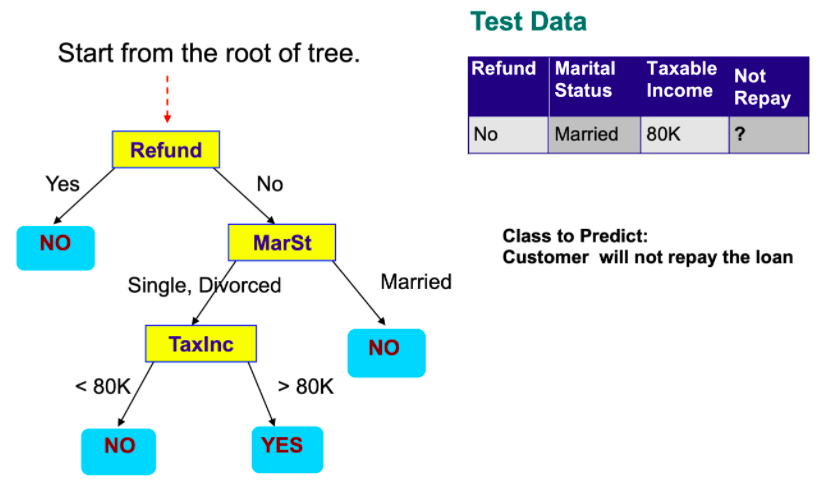

Nós então caminhamos na árvore, fazendo uma decisão em cada nó interno, o que nos leva a um novo nó.

Cada nó examina uma única característica (atributo ou *feature*) do item a ser classificado.

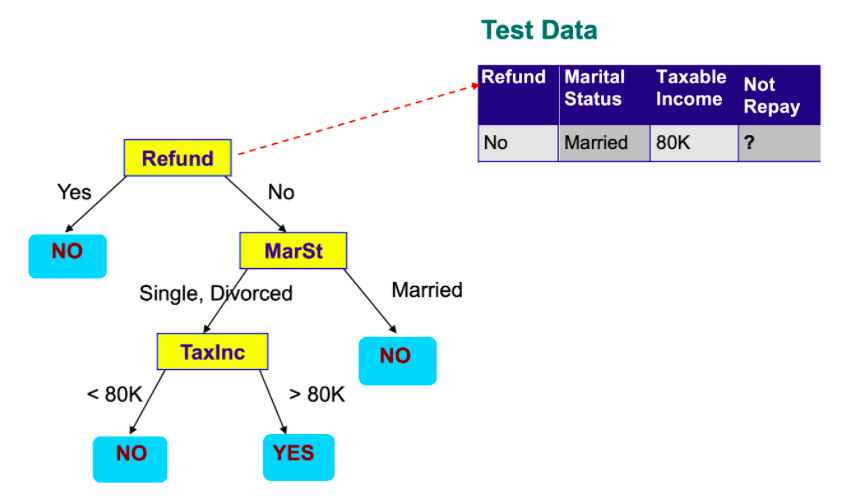

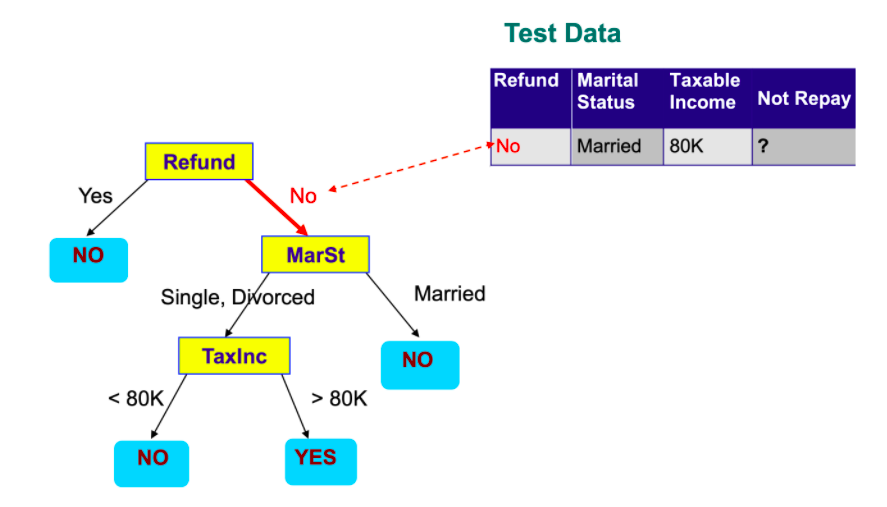

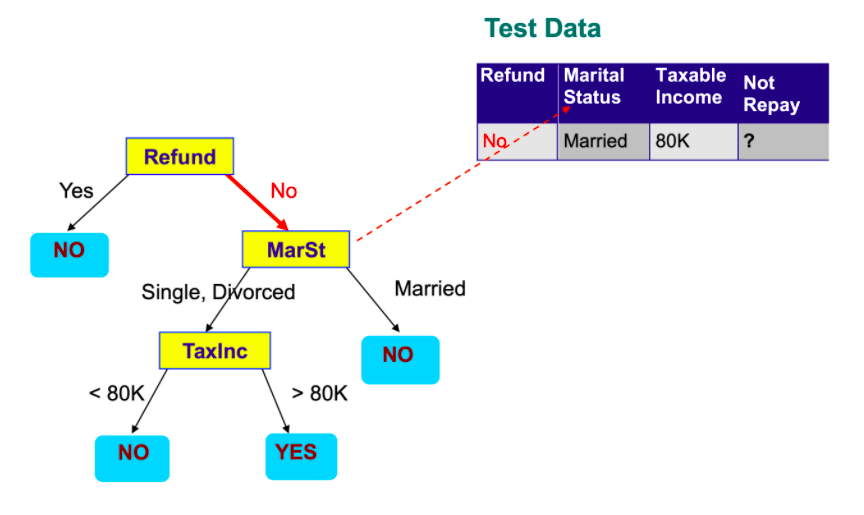

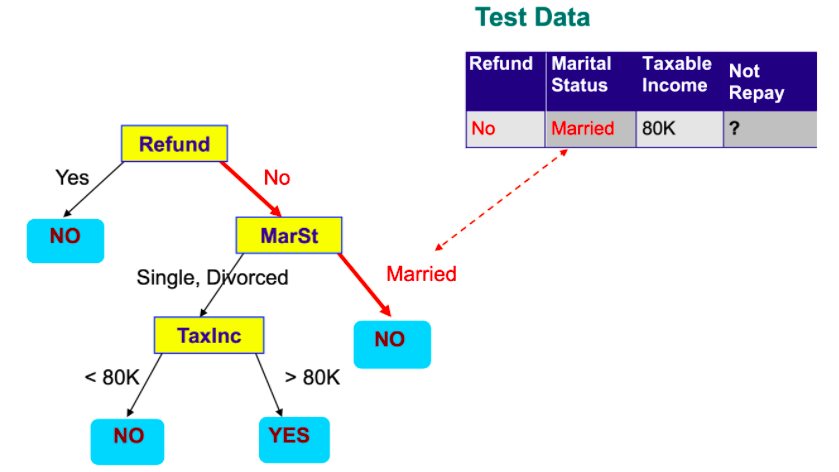

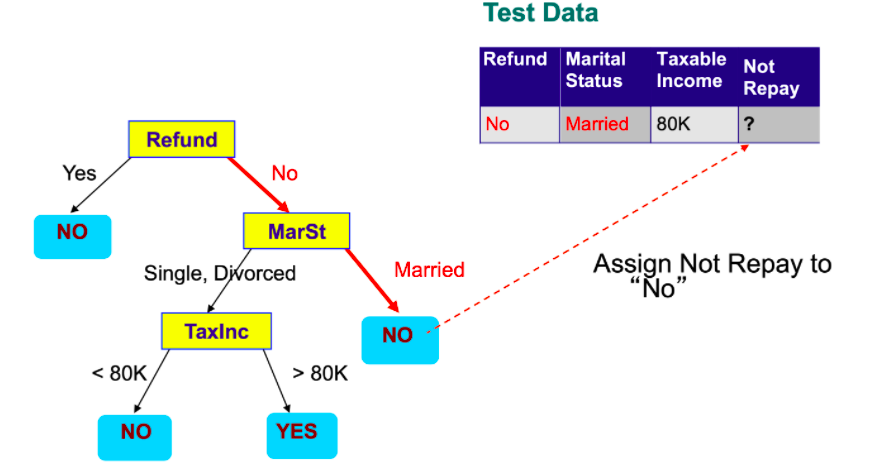

Nós concluímos que este indivíduo é classificado como **não dará "calote"**.

É importante ressaltar que árvores de decisão podem ser utilizadas também para prever valores numéricos (i.e., para regressão).

O termo *Classification and Regression Tree* (CART) é comumente utilizado -- apesar de que o termo refere-se a um tipo específico de algoritmo de criação de árvores de decisão.

## Construindo (*Learning*) uma árvore de decisão

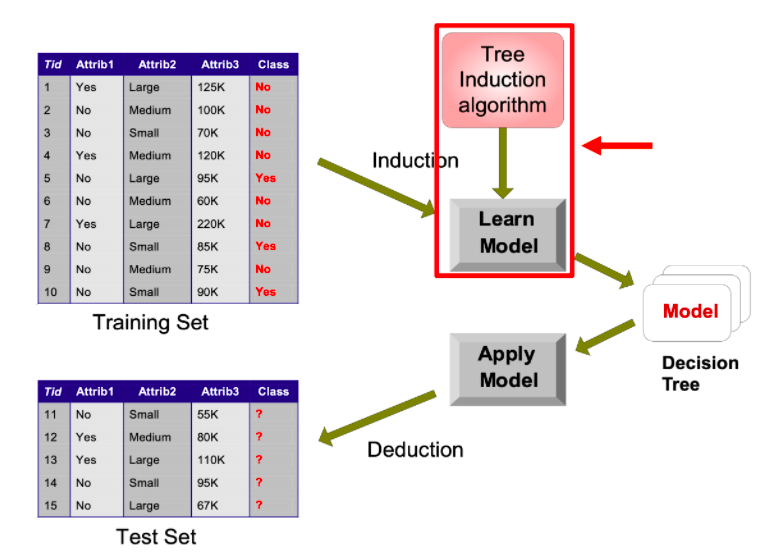

Até agora, nós dicutimos como utilizar uma ávore de decisão (parte de baixo da figura).

Como podemos construir uma? Qual algoritmo utilizar?

Vários algoritmos foram propostos ao longo dos anos (todos se baseiam em ideias similares):
1. Algoritmo de Hunt (um dos primeiros)
2. CART
3. ID3, C4.5
4. SLIQ, SPRINT
5. ...

Vamos analisar um pouco do algoritmo de Hunt (para ilustrar a ideia geral).

## Algoritmo de Hunt

O algoritmo de Hunt constrói a árvore nó por nó, começando pela raíz.

A entrada do algoritmo é o conjunto de treinamento $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$.

Durante a construção da árvore, nós dividimos o conjunto de treinamento em porções menores.

Vamos considerar o conjunto de objetos sendo analisados no nó $t$ por $D_t$. Temos as seguintes situações:
1. Se $D_t$ contém objetos pertencentes a uma única classe, $y$, então $t$ passa a ser um nó folha da classe $y$ e o processo recursivo não continua.
2. Se $D_t$ contém objetos pertencentes a mais de uma classe, **escolha** um atributo para **dividir** $D_t$ em conjuntos menores. Cada subconjunto será um nó filho do nó relativo a $D_t$. Aplique o procedimento recursivamente a cada novo nó até que algum critério de parada seja encontrado.

A parte mais desafiadora do algoritmo é decidir como especificar o processo de divisão de um nó.

Em geral, utiliza-se uma estratégia gulosa. Nós vamos dividir um nó tomando como base um teste sobre um atributo que otimize algum critério.

Perguntas importantes:
1. Como especificar o atributo a ser utilizado para dividir um conjunto?
2. Como especificar o teste sobre esse atributo?
3. Como determinar quando devemos parar de dividir um nó?

### Especificando a condição de um teste

Como especificamos um teste depende do tipo de atributo que estamos trabalhando:
- Nominal (categórico)
- Ordinal (e.g., pequeno, médio e grande)
- Contínuo

O teste também depende do tipo de divisão que podemos fazer no nó. A divisão pode ser **múltipla** (**multi-way**) ou **binária**.

#### Atributo nominal

Em uma divisão múltipla, nós podemos usar o número de partições igual ao número de valores distintos do atributo.

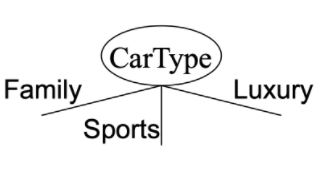

Em uma divisão binária, podemos dividir os valores de acordo com dois grupos. Nesse caso, é necessário encontrar a maneira ótima de dividir os valores em dois grupos.

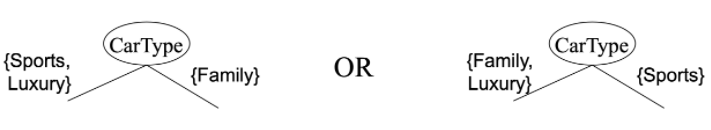

#### Atributo ordinal

Um atributo ordinal é similar a um nominal, exceto no fato de que os valores possuem uma ordem. Assim, podemos especificar o teste em termos de um limiar. Isso simplifica o processo de busca por uma partição (para divisões binárias).

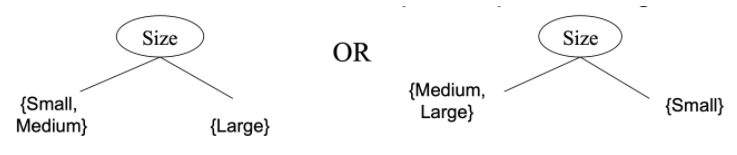

#### Atributos contínuos

Atributos numéricos/contínuos podem ser considerados de duas formas.

Eles podem ser discretizados para formar atributos ordinais.

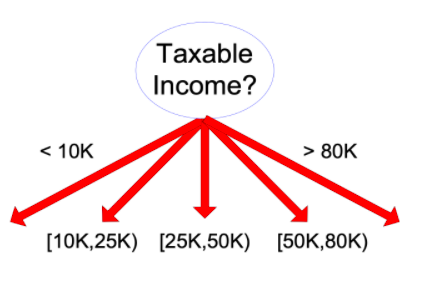

Ou podem ser particionados por meio de um limiar para formar uma divisão binária.

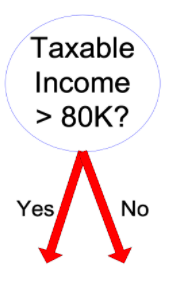

Observe que encontrar boas partições para atributos nominais pode ser uma tarefa cara, possivelmente envolvendo busca sobre um grande número de possíveis partições.

No entanto, para atributos ordinais ou contínuos, o processo é simplificado por uma varredura dos valores.

### Determinando a melhor divisão

Nossa estratégia algoritmica é dividir os conjuntos de dados de forma a melhorar a acurácia da classificação no conjunto de dados fornecido para treinar o modelo.

**Quando a acurácia da classificação é maximizada?**

Quando cada nó folha contém elementos que pertencem a mesma classe (têm o mesmo rótulo).

Considere o caso abaixo:

Em um nó da árvore, antes da divisão em filhos, nós temos:
- 10 elementos da classe 0
- 10 elementos da classe 1

Há 3 atributos que podem ser utilizados para fazer a divisão do nó. Qual divisão é melhor?

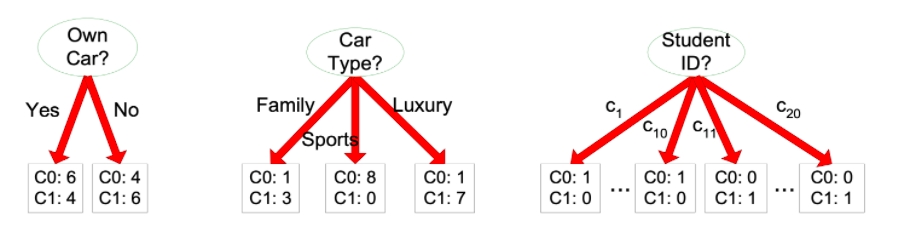

O atributo "Car Type" gera uma divisão mais homogênea.

Usar o atributo "Student ID" cria umar partição perfeita no conjunto de treinamento, mas pode gerar overfitting (veremos mais em breve).

Por agora, vamos focar apenas em maximizar a homogeneidade das divisões. Para isso, precisamos de uma forma de quantificar a pureza dos elementos de cada nó.

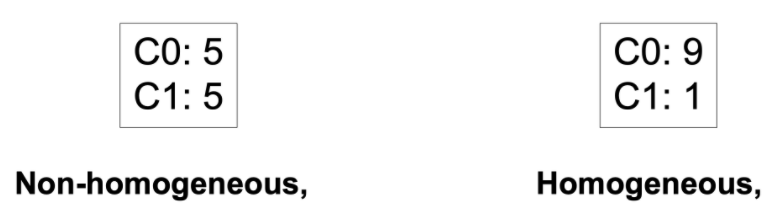

Várias medidas foram propostas ao longo dos anos.

1. Índice GINI
2. Entropia
3. Erro na classificação

Vamos utilizar o índice de GINI como exemplo, uma vez que é umas das medidas mais utilizadas.

#### Índice de GINI

Nós vamos pensar no conjunto de elementos em cada nó como uma distribuição sobre as classes.

Para um nó $t$, vamos denotar por $P(j|t)$ a frequência relativa da classe $j$ no nó $t$.

O índice de GINI mede o grau de balanceamento na distribuição. É definido por
$$1 - \sum_jP(j|t)^2.$$

À medida que nós são divididos na construção da árvore, o valor do índice de GINI diminui.

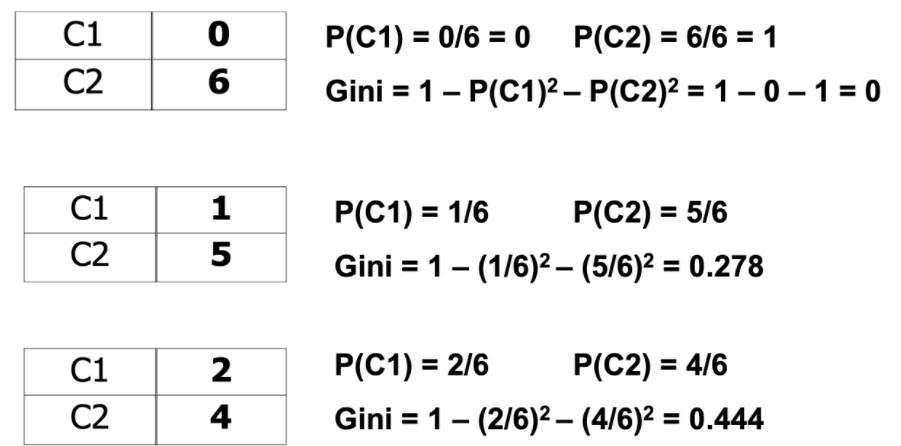

Agora, como podemos computar a melhoria no GINI quando um nó é dividido?

Lembre que queremos criar um nó grande e homogêneo.

Então, nós vamos ponderar o GINI de cada nó pelo número de elementos que ele contém.

Assim, a melhoria no GINI quando dividindo um nó com $N$ elementos é definido por:
$$\text{GINI}_{\text{NEW}} = \sum_i\frac{N_i}{N}\text{GINI}(i),$$
onde:
- $N_i$ é o numero de elementos no $i$-ésimo filho do nó $t$ e
- GINI$(i)$ é o GINI do $i$-ésimo filho do nó $t$.

Assim, uma divisão candidata tem melhoria no GINI dada por:
$$\text{GINI}(t) - \text{GINI}_{\text{NEW}}.$$


##### Exemplo para partições binárias

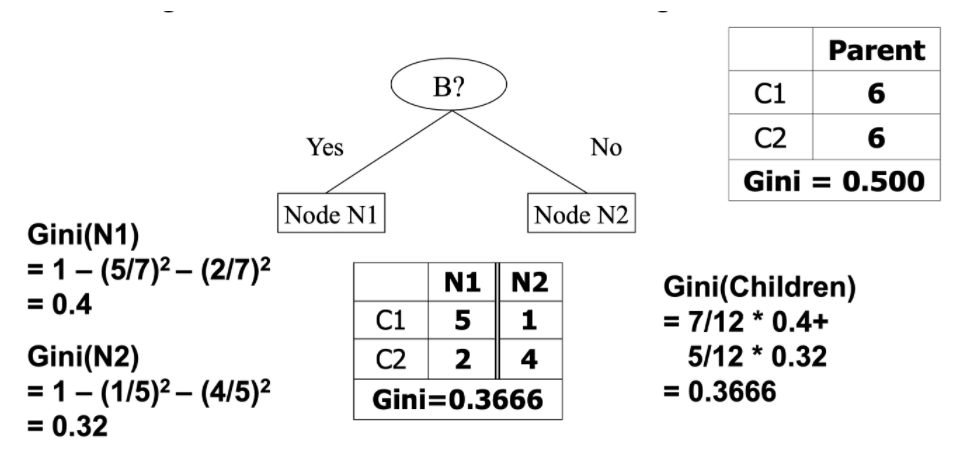

##### Exemplo para atributos nominais

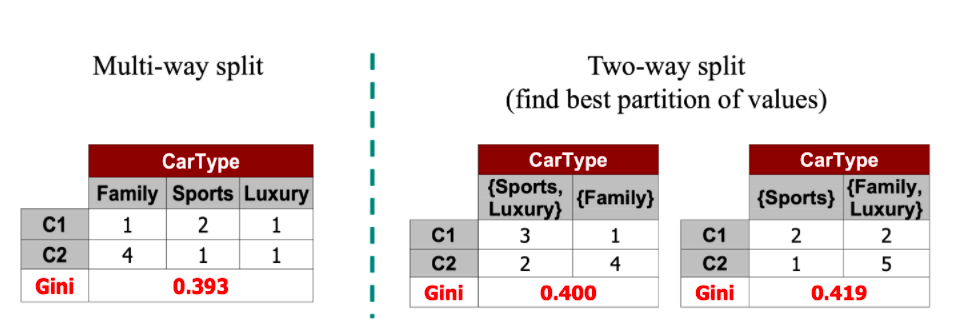

##### Exemplo para atributos contínuos

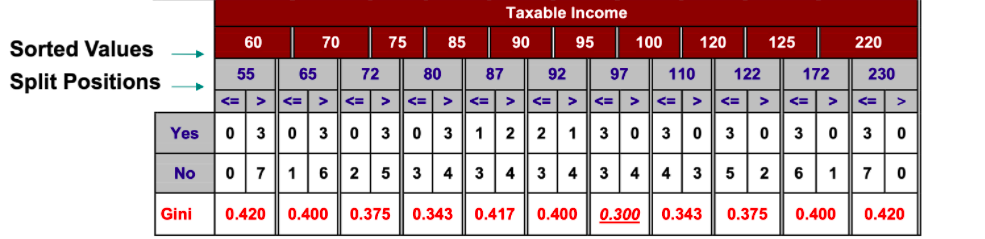

### Quando parar o processo de divisão?

Poderíamos continuar o processo de divisão até que todos os nós folha tivessem elementos pertencentes a apenas uma classe.

Por exemplo, cada nó folha poderia conter um único elemento do conjunto de treino.

Isso certamente criaria o problema de overfitting!

Há duas estratégias que podem ser utilizadas para controlar a complexidade de uma árvore de decisão:

1. *Early-stopping*: para o algoritmo antes que a árvore cresça demais
2. *Post-pruning*: cresça a ávore de descisão até que todas as folhas sejam completamente puras e após isso, faça um processo de poda.

*Early-stopping* é uma estratégia mais comum. Entre os possíveis critérios:
1. Pare se o número de elementos em um nó for menor que um valor definido
2. Pare se o processo de divisão for incapaz de melhorar a homogeneidade
3. Pare se a divisão for criar um nó com um número de elementos menor que um valor definido.

## Interpretação

Árvores de decisão são muito populares para classificação.

Elas têm as seguintes vantagens:
- Podem ser construídas de forma eficiente
- São eficientes para classificar novos elementos
- Têm boa acurácia em muitas situações
- São fáceis de ser **interpretadas**.

## Com a biblioteca ``Scikit-learn``

Utilizando o conhecido conjunto de dados ``wine``, vamos ver como a implementação de Árvore de Decisão da biblioteca ``scikit-learn`` funciona.

Para detalhes, recomenda-se a leitura da documentação da classe [``DecisionTreeClassifier``](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

Abaixo, os dados são obtidos e é feita a divisão entre treino e teste.

In [ ]:
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings('ignore')

# obtendo os dados
wine = load_wine(return_X_y = False, as_frame = True)
X = wine.data
y = wine.target.values

# devidindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

Em seguida, fazemos o ajuste e teste do modelo.

In [ ]:
# Criando e ajustando o modelo
model = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 15)
model.fit(X_train, y_train)

# Realizando a previsão para os dados de teste
y_pred = model.predict(X_test);

# Medindo a acurácia do modelo nos dados de teste
acc = accuracy_score(y_test, y_pred)
print("Acurácia do Classificador = %f" % acc);

Acurácia do Classificador = 0.907407


**Observações importantes:**

1. Diferentemente dos classificadores das aulas passadas, veja que nesse exemplo não realizamos a Padronização ou transformação por reescala dos dados. Árvores de Decisão não são diretamente baseadas nas distâncias entre objetos, mas sim em operações de comparação. Por isso, em geral, ajustar as ordens de grandeza das características não contribui significativamente para o desempenho do classificador.

2. Assim como os demais classificadores que vimos, Árvores de Decisão possuem vários hiperparâmetros (quantidades a serem informadas pelo usuário). No exemplo, utilizamos ``max_depth`` e ``min_samples_leaf``. Esses atributos indicam que a Árvore do modelo treinado não poderá ter altura maior que 3 e que os nós folhas da árvore não poderão conter menos do que 5 objetos (no treinamento). Há vários outros hiperparâmetros importantes para esse classificador. Recomenda-se a leitura da documentação! Veremos mais sobre hiperparâmetros em aulas futuras.

### É possível visualizar a Árvore!

Uma das maiores vantagens de se utilizar uma Árvore de Decisão é o fato de ela poder ser **visualizada** e **interpretada**.

A Árvore do exemplo acima é mostrada a seguir. Veja que podemos explicar a classificação de qualquer elemento!

In [ ]:
import graphviz
import pydotplus
from sklearn import tree

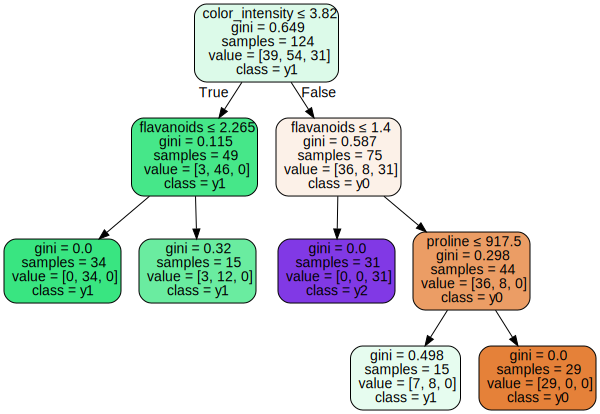

In [ ]:
dot_data = tree.export_graphviz(model, out_file=None,
                     filled=True, rounded=True,
                     special_characters=True, feature_names = X.columns, class_names = True)

graph = graphviz.Source(dot_data)
graph.render("dt-vis",view = True)
graph

## Exemplo - Visualizando *overfitting* com Árvores de Decisão


Agora, vamos visualizar o fenômeno de *overfitting* utilizando uma Árvore de Decisão.

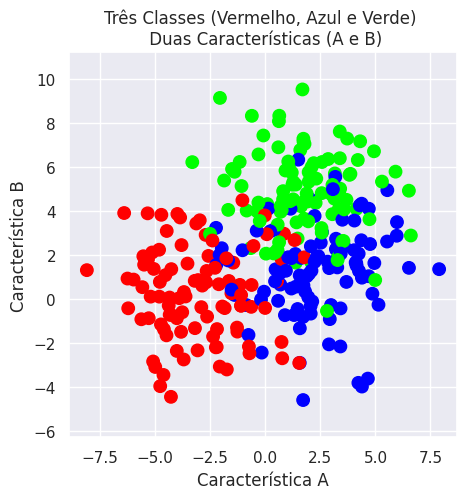

In [ ]:
#@title Conjunto de Dados
import sklearn.datasets as sk_data
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

X, y = sk_data.make_blobs(n_samples=300,
                          centers=[[-3, 0],[2, 5], [2.5, 1.5]],
                          #centers=[[-2, 0],[1, 5], [2.5, 1.5]],
                          cluster_std = [2, 2, 2],
                          #cluster_std = [2, 2, 2],
                          n_features=2,
                          center_box=(-10.0, 10.0),random_state=0)
plt.figure(figsize = (5,5))
plt.axis('equal')
plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold, s = 80);

plt.xlabel('Característica A')
plt.ylabel('Característica B')
plt.title('Três Classes (Vermelho, Azul e Verde) \n Duas Características (A e B)');

Primeiro, vamos construir uma árvore sem restrições. O resultado, apresentado abaixo, mostra que é um modelo grande e complexo.

In [ ]:
import sklearn.tree as tree

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30,
                                                    random_state = 7)

dtc = tree.DecisionTreeClassifier()
dtc.fit(X_train, y_train);

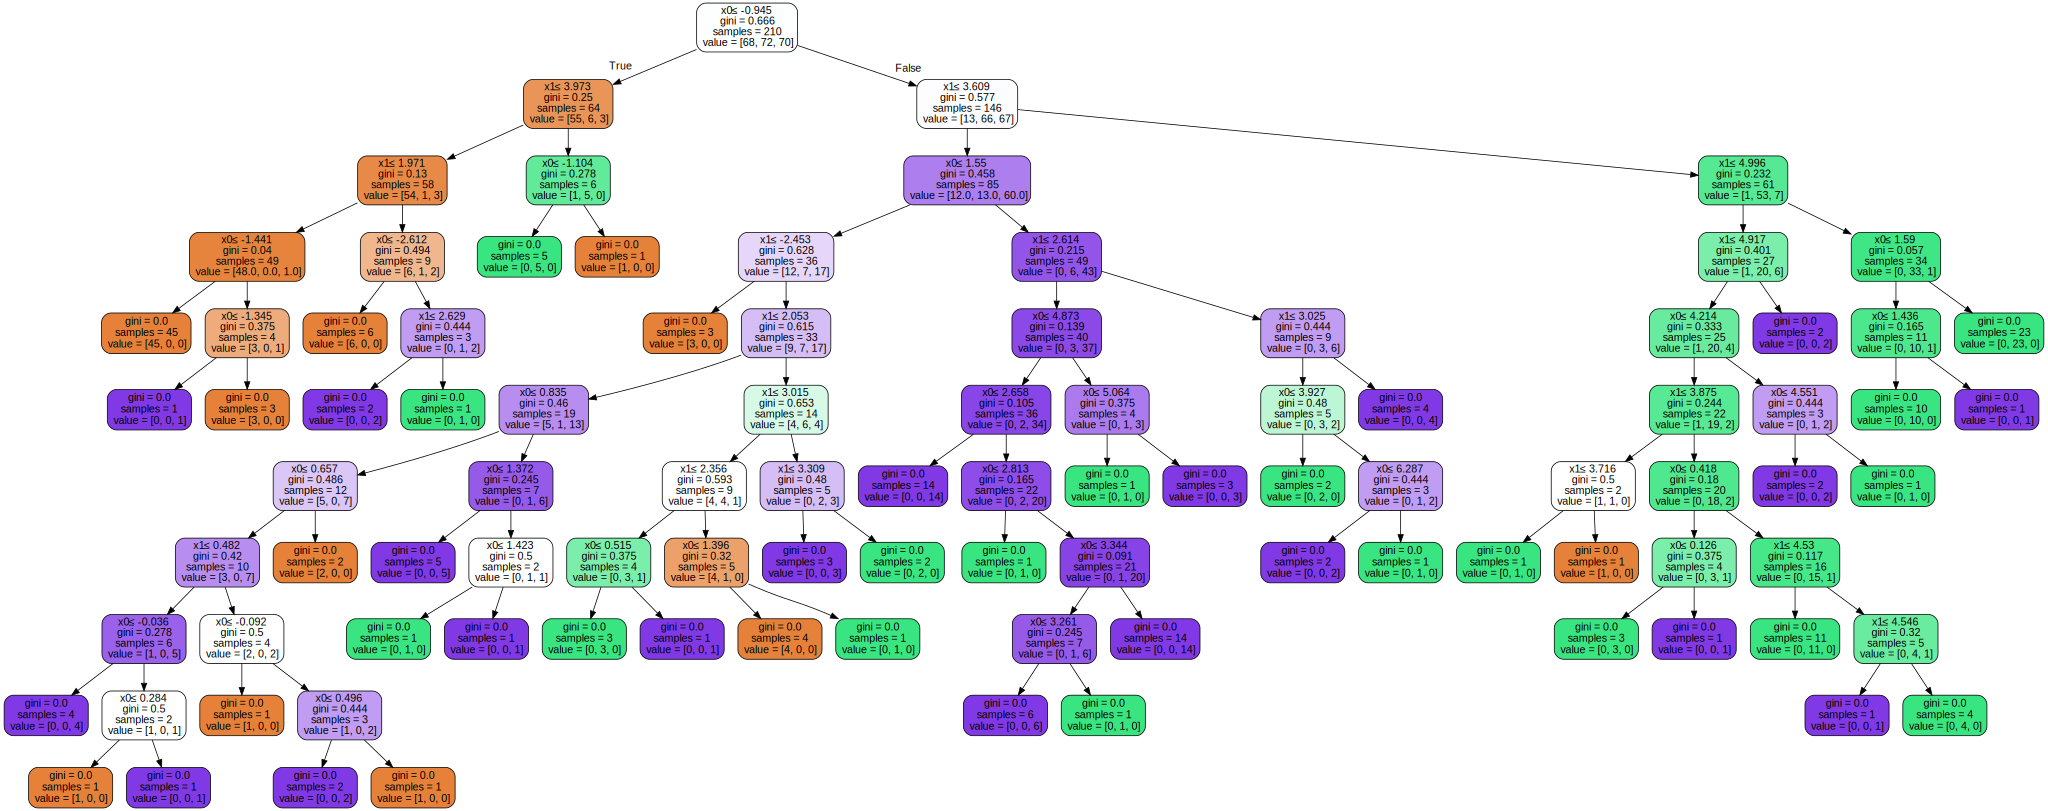

In [ ]:
#@title Árvore de Decisão para o conjunto de dados do exemplo anterior
import graphviz
import pydotplus

dot_data = tree.export_graphviz(dtc, out_file=None,
                     filled=True, rounded=True,
                     special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("dt-vis",view = True)
graph

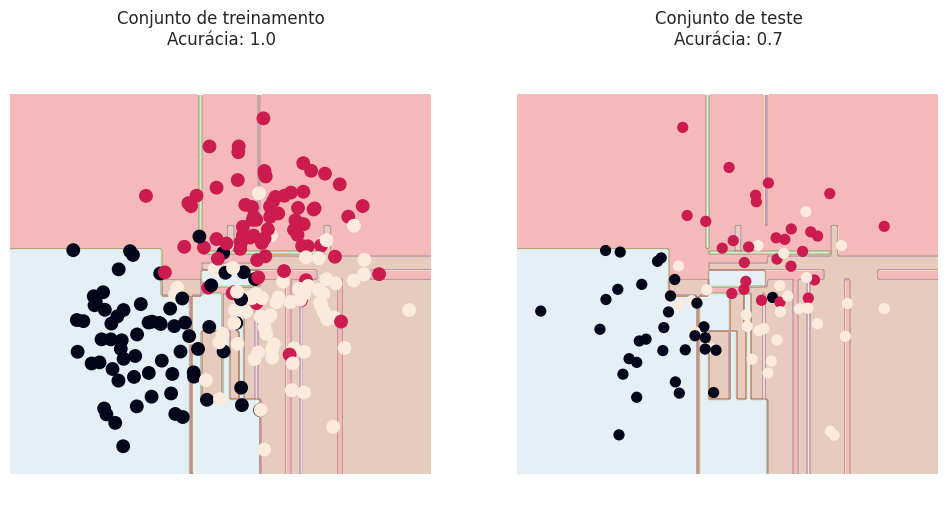

In [ ]:
#@title Regiões de Decisão e desempenho do classificador nos conjuntos de treinamento e teste
Z = dtc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, s = 80)
plt.axis('equal')
plt.axis('off')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.title(f'Conjunto de treinamento\nAcurácia: {dtc.score(X_train, y_train)}');

plt.subplot(1, 2, 2)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, s = 50)
plt.axis('equal')
plt.axis('off')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.title(f'Conjunto de teste\nAcurácia: {dtc.score(X_test, y_test)}');


Pode-se perceber, que o modelo treinado é especializado para o conjunto de treinamento, não conseguindo se adaptar a dados do conjunto de teste. Novamente, isso ilustra o fenômeno de *overfitting*.

Vamos agora restringir a complexidade do modelo. Para isso, usaremos o hiperparâmetro ``min_samples_leaf``, para informar que as folhas da árvore devem ter ao menos 10 objetos do conjunto de treinamento.

In [ ]:
dtc = tree.DecisionTreeClassifier(min_samples_leaf = 10)
dtc.fit(X_train, y_train);

Abaixo, pode-se perceber que o Árvore gerada é consideravelmente menor.

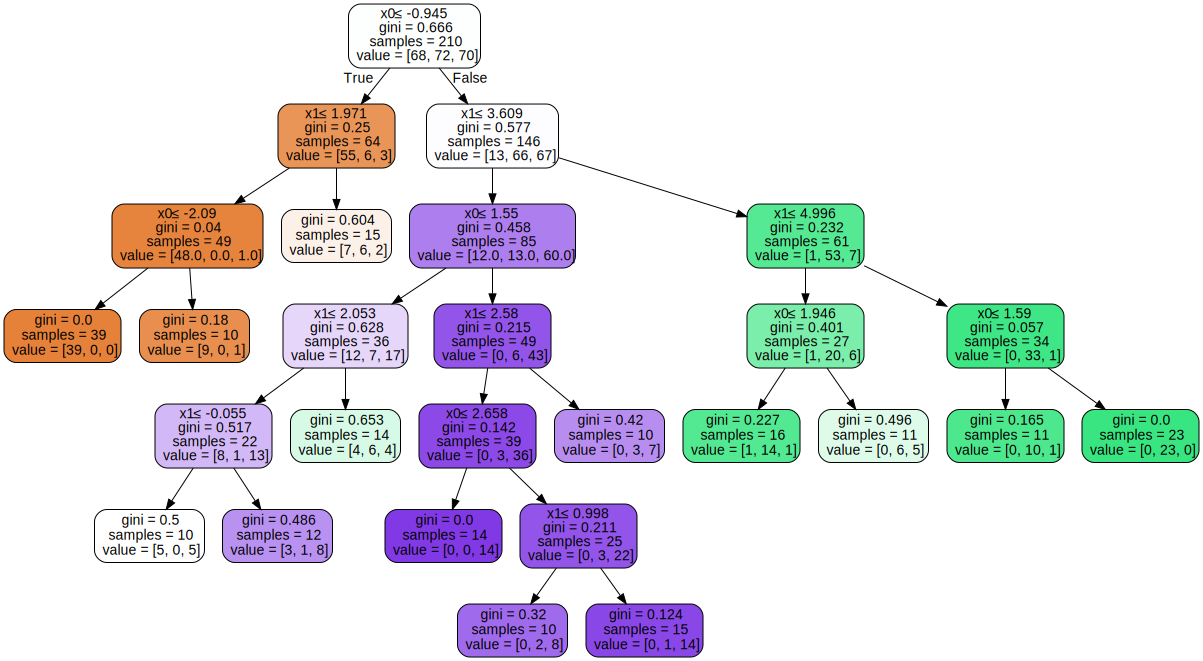

In [ ]:
#@title Árvore de Decisão para o conjunto de dados do exemplo anterior
import graphviz
import pydotplus

dot_data = tree.export_graphviz(dtc, out_file=None,
                     filled=True, rounded=True,
                     special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("dt-vis",view = True)
graph

Qual o impacto dessa mudança no desempenho do classificador?

Veja que o desempenho do classificador melhora significativamente no conjunto de teste!

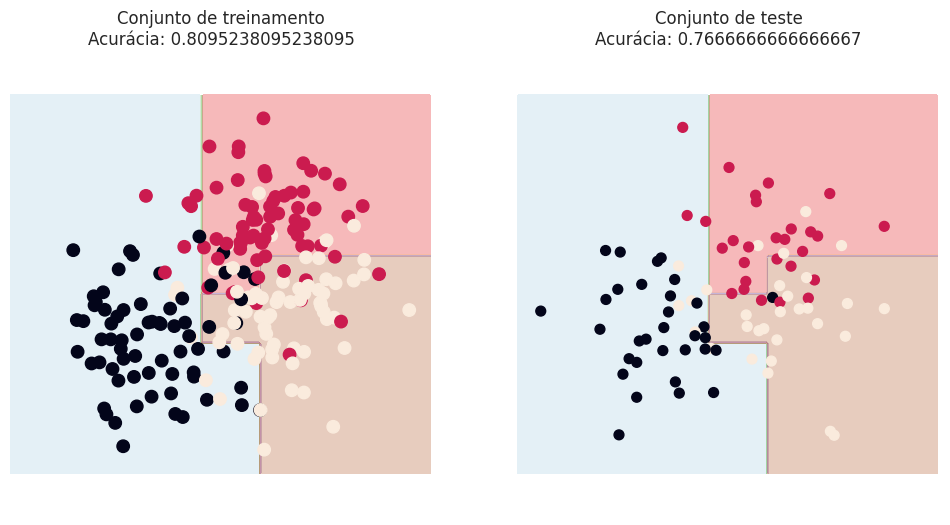

In [ ]:
#@title Regiões de Decisão e desempenho do classificador nos conjuntos de treinamento e teste
Z = dtc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, s = 80)
plt.axis('equal')
plt.axis('off')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.title(f'Conjunto de treinamento\nAcurácia: {dtc.score(X_train, y_train)}');

plt.subplot(1, 2, 2)
cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, s = 50)
plt.axis('equal')
plt.axis('off')
plt.xlim((x_min, x_max))
plt.ylim((y_min, y_max))
plt.title(f'Conjunto de teste\nAcurácia: {dtc.score(X_test, y_test)}');


Veja que ao diminuir a complexidade, o modelo perde a capacidade de "decorar" o conjunto de treinamento e, assim, consegue melhor generalização para novos dados (i.e., conjunto de teste).

Em aulas futuras, veremos procedimentos para treinar bons modelos e evitar *overfitting* de maneira automática.

# What is next?

- Como avaliar um modelo de classificação?